# 🤖 03 — Modeling: Baseline, ARIMA & SARIMAX Benchmark

## Hormuz Strait Shipping Disruption — Daily Ship Transits

**Goal:** Train and compare 8 forecasting models on a proper chronological train/test split, establish baselines, and select the best-performing model for final forecasting in notebook 04.

> ⚠️ All models are trained **only on the train set** and evaluated on the **held-out test set** — no in-sample evaluation is used for accuracy claims.

## 1. Set up and import

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import (
    SimpleExpSmoothing,
    ExponentialSmoothing
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

# Import project modules
from data_loader import (
    load_raw_data,
    validate_data,
    get_time_series,
    train_test_split_ts,
    get_exog_features
)

from evaluate import (
    compute_all_metrics,
    build_comparison_table,
    plot_comparison_table,
    plot_residuals
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (13,5)

print("All imports successful ✓")

All imports successful ✓


## 2. Load Data & Chronological Train/Test Split

We hold out the **last 15 days** as the test set.

All models are trained on days **1–110** and evaluated on days **111–125**.

In [2]:
data = load_raw_data(
    "../data/raw/strait_of_hormuz_shipping_disruption_2026.csv"
)

data = validate_data(data)
ts = get_time_series(data)

TEST_SIZE = 15

train, test = train_test_split_ts(
    ts,
    test_size=TEST_SIZE
)

print(
    f"Train: {len(train)} observations "
    f"| {train.index[0].date()} → {train.index[-1].date()}"
)

print(
    f"Test : {len(test)} observations "
    f"| {test.index[0].date()} → {test.index[-1].date()}"
)

2026-06-19 14:22:11,370 [INFO] data_loader: Loading raw data from '..\data\raw\strait_of_hormuz_shipping_disruption_2026.csv'
2026-06-19 14:22:11,418 [INFO] data_loader: Loaded 125 rows x 26 columns | Date range: 2026-01-01 to 2026-05-05
2026-06-19 14:22:11,419 [INFO] data_loader: Running data validation checks...
2026-06-19 14:22:11,431 [INFO] data_loader: No duplicate rows found ✓
2026-06-19 14:22:11,432 [INFO] data_loader: No duplicate dates found ✓
2026-06-19 14:22:11,432 [INFO] data_loader: No missing values in target column ✓
2026-06-19 14:22:11,436 [INFO] data_loader: No missing values in any column ✓
2026-06-19 14:22:11,442 [INFO] data_loader: Data is chronologically ordered ✓
2026-06-19 14:22:11,456 [INFO] data_loader: Extracted time series: 125 observations
2026-06-19 14:22:11,459 [INFO] data_loader: Train: 110 obs (2026-01-01 → 2026-04-20) | Test: 15 obs (2026-04-21 → 2026-05-05)


Train: 110 observations | 2026-01-01 → 2026-04-20
Test : 15 observations | 2026-04-21 → 2026-05-05


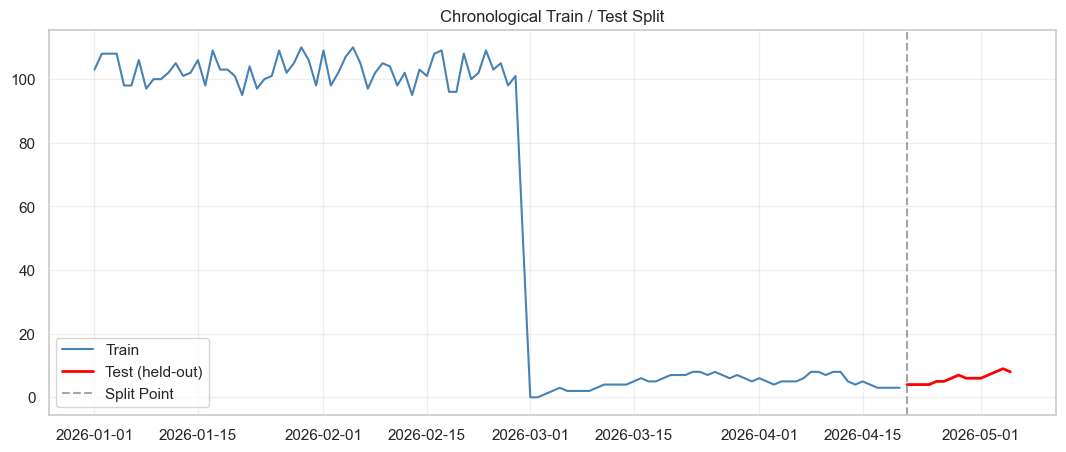

In [3]:
# Visualize chronological split

plt.figure(figsize=(13,5))

plt.plot(
    train.index,
    train.values,
    label="Train",
    color="steelblue"
)

plt.plot(
    test.index,
    test.values,
    label="Test (held-out)",
    color="red",
    linewidth=2
)

plt.axvline(
    test.index[0],
    color="gray",
    linestyle="--",
    alpha=0.7,
    label="Split Point"
)

plt.title("Chronological Train / Test Split")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Helper Function

Store the evaluation metrics of every forecasting model so they can be compared later.

In [4]:
results = []


def evaluate_and_store(name, pred_series, actual=test):
    metrics = compute_all_metrics(
        actual,
        pred_series,
        model_name=name
    )

    results.append(metrics)
    return metrics

## 3. Naive Forecast (Baseline 1)

### Theory

The **Naive Forecast** predicts every future observation as the **last value observed in the training set**.

It is the simplest forecasting benchmark and provides a minimum performance level that every advanced forecasting model should outperform.

In [5]:
last_value = float(train.iloc[-1])

naive_pred = pd.Series(
    [last_value] * TEST_SIZE,
    index=test.index
)

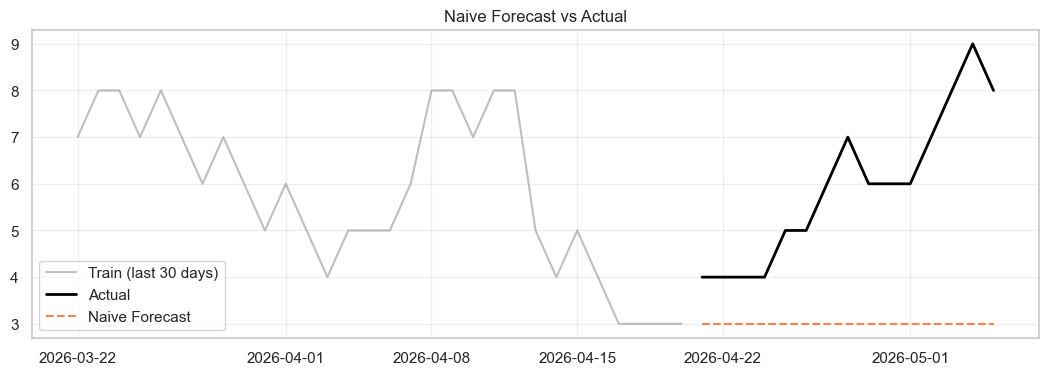

In [6]:
plt.figure(figsize=(13,4))

plt.plot(
    train.index[-30:],
    train.values[-30:],
    color="gray",
    alpha=0.5,
    label="Train (last 30 days)"
)

plt.plot(
    test.index,
    test.values,
    color="black",
    linewidth=2,
    label="Actual"
)

plt.plot(
    test.index,
    naive_pred,
    "--",
    color="coral",
    label="Naive Forecast"
)

plt.title("Naive Forecast vs Actual")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [7]:
evaluate_and_store(
    "Naive",
    naive_pred
)

2026-06-19 14:24:29,925 [INFO] evaluate: [Naive] MAE=2.9333 | RMSE=3.3267 | MAPE=45.73% | DirAcc=42.9%


{'Model': 'Naive',
 'MAE': 2.933333333333333,
 'RMSE': 3.32665998663324,
 'MAPE': 45.730158730158735,
 'DirectionalAcc(%)': 42.857142857142854}

## 4. Moving Average Forecast (Baseline 2)

### Theory

The **Moving Average Forecast** predicts future observations using the average of the most recent observations.

Compared with the Naive Forecast, it reduces short-term fluctuations and smooths random noise while remaining a very simple benchmark.

In [8]:
WINDOW = 7

moving_average_value = float(
    train.tail(WINDOW).mean()
)

ma_pred = pd.Series(
    [moving_average_value] * TEST_SIZE,
    index=test.index
)

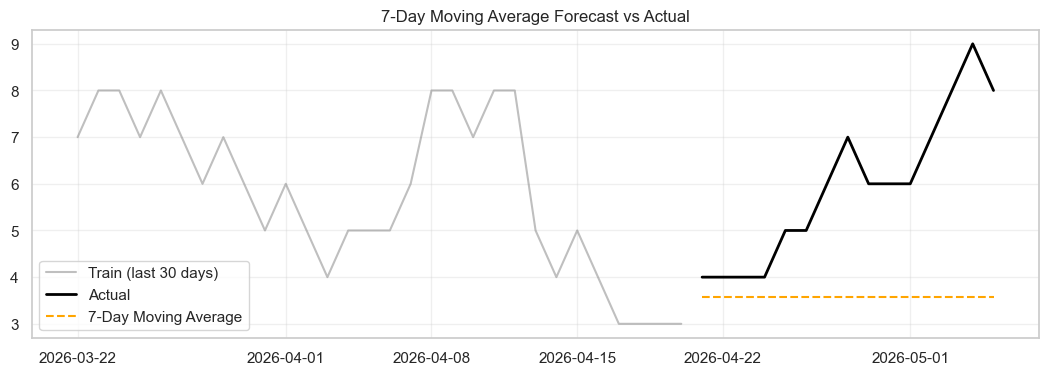

In [9]:
plt.figure(figsize=(13,4))

plt.plot(
    train.index[-30:],
    train.values[-30:],
    color="gray",
    alpha=0.5,
    label="Train (last 30 days)"
)

plt.plot(
    test.index,
    test.values,
    color="black",
    linewidth=2,
    label="Actual"
)

plt.plot(
    test.index,
    ma_pred,
    "--",
    color="orange",
    label=f"{WINDOW}-Day Moving Average"
)

plt.title(f"{WINDOW}-Day Moving Average Forecast vs Actual")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [10]:
evaluate_and_store(
    f"MovingAverage({WINDOW}d)",
    ma_pred
)

2026-06-19 14:25:03,785 [INFO] evaluate: [MovingAverage(7d)] MAE=2.3619 | RMSE=2.8356 | MAPE=35.39% | DirAcc=42.9%


{'Model': 'MovingAverage(7d)',
 'MAE': 2.361904761904762,
 'RMSE': 2.835633320182744,
 'MAPE': 35.39304610733183,
 'DirectionalAcc(%)': 42.857142857142854}

## 5. Simple Exponential Smoothing (SES)

### Theory

**Simple Exponential Smoothing (SES)** forecasts future values by computing a weighted average of all previous observations, where more recent observations receive exponentially larger weights.

Unlike the Moving Average method, SES automatically determines the optimal smoothing parameter (**α**) during model fitting, allowing the model to adapt more effectively to recent changes in the time series.

This method is appropriate when the data exhibit **no clear trend or seasonality**.

In [11]:
ses_model = SimpleExpSmoothing(
    train,
    initialization_method="estimated"
).fit()

ses_pred_raw = ses_model.forecast(TEST_SIZE)

ses_pred = pd.Series(
    ses_pred_raw.values,
    index=test.index
)

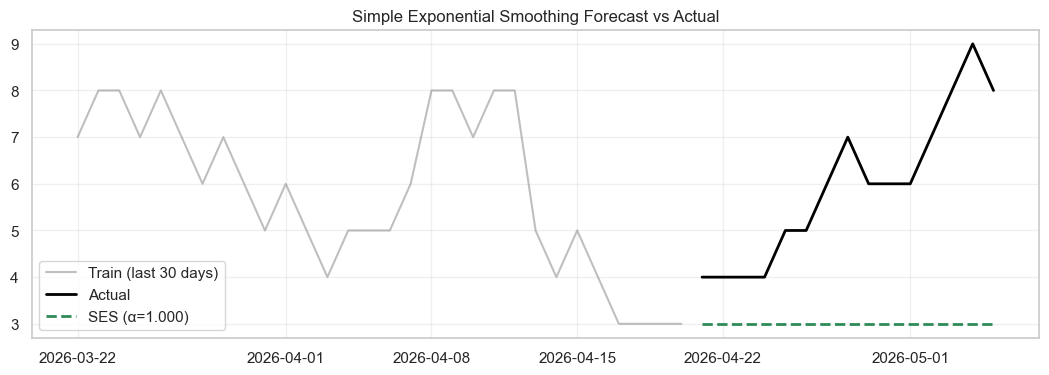

In [12]:
plt.figure(figsize=(13,4))

plt.plot(
    train.index[-30:],
    train.values[-30:],
    color="gray",
    alpha=0.5,
    label="Train (last 30 days)"
)

plt.plot(
    test.index,
    test.values,
    color="black",
    linewidth=2,
    label="Actual"
)

plt.plot(
    test.index,
    ses_pred,
    "--",
    color="seagreen",
    linewidth=2,
    label=f"SES (α={ses_model.params['smoothing_level']:.3f})"
)

plt.title("Simple Exponential Smoothing Forecast vs Actual")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [13]:
evaluate_and_store(
    "Exp.Smoothing(SES)",
    ses_pred
)

2026-06-19 14:26:37,371 [INFO] evaluate: [Exp.Smoothing(SES)] MAE=2.9333 | RMSE=3.3267 | MAPE=45.73% | DirAcc=42.9%


{'Model': 'Exp.Smoothing(SES)',
 'MAE': 2.933333333333333,
 'RMSE': 3.32665998663324,
 'MAPE': 45.730158730158735,
 'DirectionalAcc(%)': 42.857142857142854}

## 6. Holt–Winters Exponential Smoothing

### Theory

The **Holt–Winters model** extends exponential smoothing by incorporating both **trend** and **seasonal** components.

This notebook uses:

- **Additive Trend**
- **Additive Seasonality**
- **Weekly Seasonal Period (7 days)**

The model estimates three smoothing parameters:

- **α (alpha):** level
- **β (beta):** trend
- **γ (gamma):** seasonality

Holt–Winters is suitable when the series exhibits repeating seasonal patterns in addition to an overall trend.

In [14]:
hw_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=7,
    initialization_method="estimated"
).fit()

hw_pred_raw = hw_model.forecast(TEST_SIZE)

hw_pred = pd.Series(
    hw_pred_raw.values,
    index=test.index
)

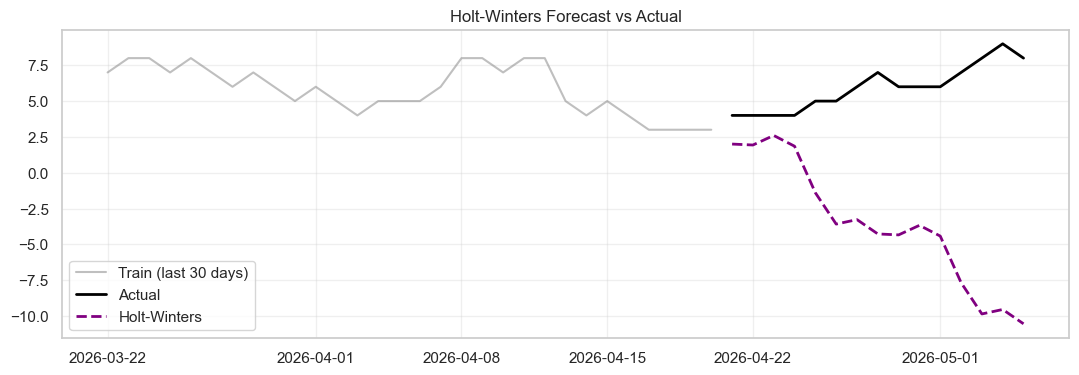

In [15]:
plt.figure(figsize=(13,4))

plt.plot(
    train.index[-30:],
    train.values[-30:],
    color="gray",
    alpha=0.5,
    label="Train (last 30 days)"
)

plt.plot(
    test.index,
    test.values,
    color="black",
    linewidth=2,
    label="Actual"
)

plt.plot(
    test.index,
    hw_pred,
    "--",
    color="purple",
    linewidth=2,
    label="Holt-Winters"
)

plt.title("Holt-Winters Forecast vs Actual")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [16]:
evaluate_and_store(
    "Holt-Winters",
    hw_pred
)

2026-06-19 14:27:06,753 [INFO] evaluate: [Holt-Winters] MAE=9.5492 | RMSE=11.1794 | MAPE=145.61% | DirAcc=28.6%


{'Model': 'Holt-Winters',
 'MAE': 9.549205276865253,
 'RMSE': 11.179400524798808,
 'MAPE': 145.61140033182178,
 'DirectionalAcc(%)': 28.57142857142857}

## 7. AutoRegressive Integrated Moving Average (ARIMA)

### Theory

The **ARIMA** model combines three fundamental components of time-series forecasting:

- **AR (AutoRegressive):** dependence on previous observations.
- **I (Integrated):** differencing used to make the series stationary.
- **MA (Moving Average):** dependence on previous forecast errors.

The model is represented as **ARIMA(p, d, q)** where:

- **p:** autoregressive order
- **d:** differencing order
- **q:** moving-average order

Based on the stationarity tests and ACF/PACF analysis performed in Notebook 02, **ARIMA(1,1,1)** is selected as the candidate model.

In [17]:
arima_model = ARIMA(
    train,
    order=(1,1,1)
).fit()

print(arima_model.summary())

                                SARIMAX Results                                
Dep. Variable:     daily_ship_transits   No. Observations:                  110
Model:                  ARIMA(1, 1, 1)   Log Likelihood                -381.258
Date:                 Fri, 19 Jun 2026   AIC                            768.515
Time:                         14:27:21   BIC                            776.589
Sample:                     01-01-2026   HQIC                           771.790
                          - 04-20-2026                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2464      0.580     -0.425      0.671      -1.383       0.890
ma.L1          0.4446      0.539      0.824      0.410      -0.613       1.502
sigma2        63.8926      3.792     16.851 

In [18]:
arima_forecast = arima_model.get_forecast(
    steps=TEST_SIZE
)

arima_pred = pd.Series(
    arima_forecast.predicted_mean.values,
    index=test.index
)

arima_ci = arima_forecast.conf_int(alpha=0.05)
arima_ci.index = test.index

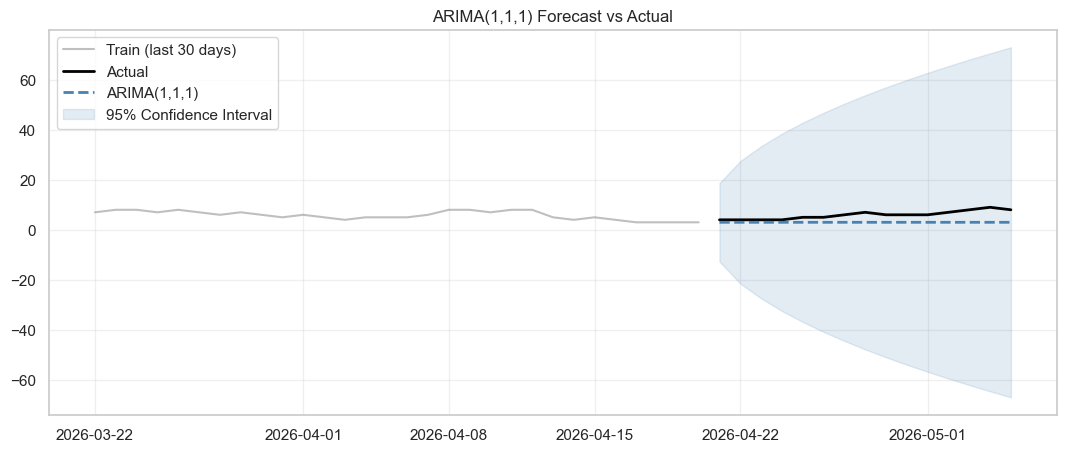

In [19]:
plt.figure(figsize=(13,5))

plt.plot(
    train.index[-30:],
    train.values[-30:],
    color="gray",
    alpha=0.5,
    label="Train (last 30 days)"
)

plt.plot(
    test.index,
    test.values,
    color="black",
    linewidth=2,
    label="Actual"
)

plt.plot(
    test.index,
    arima_pred,
    "--",
    color="steelblue",
    linewidth=2,
    label="ARIMA(1,1,1)"
)

plt.fill_between(
    test.index,
    arima_ci.iloc[:,0],
    arima_ci.iloc[:,1],
    alpha=0.15,
    color="steelblue",
    label="95% Confidence Interval"
)

plt.title("ARIMA(1,1,1) Forecast vs Actual")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [20]:
evaluate_and_store(
    "ARIMA(1,1,1)",
    arima_pred
)

2026-06-19 14:36:42,460 [INFO] evaluate: [ARIMA(1,1,1)] MAE=2.9280 | RMSE=3.3220 | MAPE=45.63% | DirAcc=21.4%


{'Model': 'ARIMA(1,1,1)',
 'MAE': 2.927994532365393,
 'RMSE': 3.321993725894585,
 'MAPE': 45.63310153863046,
 'DirectionalAcc(%)': 21.428571428571427}

## 8. Seasonal AutoRegressive Integrated Moving Average (SARIMA)

### Theory

**SARIMA (Seasonal ARIMA)** extends the ARIMA model by incorporating seasonal autoregressive, differencing, and moving-average components.

The model is expressed as:

\[
SARIMA(p,d,q)(P,D,Q,s)
\]

where:

- **(p,d,q)** represent the non-seasonal ARIMA parameters.
- **(P,D,Q)** represent the seasonal ARIMA parameters.
- **s** is the seasonal period.

For this project, a **weekly seasonal cycle (s = 7 days)** is assumed because shipping activity often follows weekly operational patterns.

In [21]:
sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

In [22]:
sarima_forecast = sarima_model.get_forecast(
    steps=TEST_SIZE
)

sarima_pred = pd.Series(
    sarima_forecast.predicted_mean.values,
    index=test.index
)

sarima_ci = sarima_forecast.conf_int(alpha=0.05)
sarima_ci.index = test.index

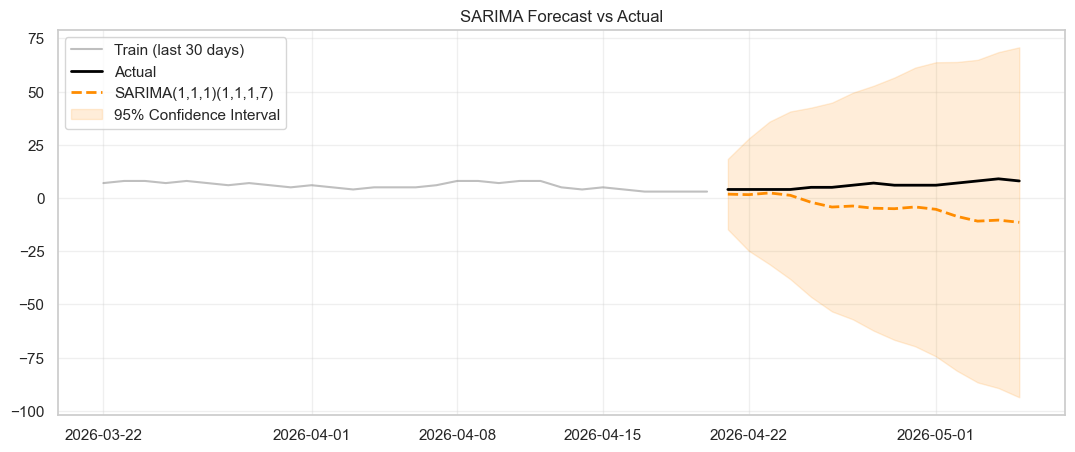

In [23]:
plt.figure(figsize=(13,5))

plt.plot(
    train.index[-30:],
    train.values[-30:],
    color="gray",
    alpha=0.5,
    label="Train (last 30 days)"
)

plt.plot(
    test.index,
    test.values,
    color="black",
    linewidth=2,
    label="Actual"
)

plt.plot(
    test.index,
    sarima_pred,
    "--",
    color="darkorange",
    linewidth=2,
    label="SARIMA(1,1,1)(1,1,1,7)"
)

plt.fill_between(
    test.index,
    sarima_ci.iloc[:,0],
    sarima_ci.iloc[:,1],
    alpha=0.15,
    color="darkorange",
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast vs Actual")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [24]:
evaluate_and_store(
    "SARIMA(1,1,1)(1,1,1,7)",
    sarima_pred
)

2026-06-19 14:37:22,912 [INFO] evaluate: [SARIMA(1,1,1)(1,1,1,7)] MAE=10.1922 | RMSE=11.8371 | MAPE=156.32% | DirAcc=28.6%


{'Model': 'SARIMA(1,1,1)(1,1,1,7)',
 'MAE': 10.192196729927439,
 'RMSE': 11.837145640644126,
 'MAPE': 156.32263471610827,
 'DirectionalAcc(%)': 28.57142857142857}

## 9. Seasonal ARIMA with Exogenous Variables (SARIMAX)

### Theory

While SARIMA models only the historical values of the target series, **SARIMAX** incorporates additional explanatory variables (exogenous regressors) that may influence the forecasting target.

In this project, two external predictors are included:

1. **War Dummy Variable**
   - 0 = Pre-war period
   - 1 = War crisis period

2. **Cumulative Number of Attacked Vessels**

These variables were identified during the exploratory analysis as major drivers of shipping activity after the onset of the conflict.

In [25]:
# Build exogenous features

exog_cols = [
    "vessels_attacked_cumulative"
]

exog_df = get_exog_features(
    data,
    feature_cols=exog_cols
)

data_indexed = data.set_index("date")

war_dummy = (
    data_indexed["period_type"] == "war_crisis"
).astype(float)

exog_df["war_dummy"] = war_dummy

2026-06-19 14:37:33,377 [INFO] data_loader: Extracted 1 exogenous feature(s): ['vessels_attacked_cumulative']


In [26]:
exog_train = exog_df.loc[train.index]
exog_test = exog_df.loc[test.index]

print("Training Exogenous Variables")
exog_train.tail()

Training Exogenous Variables


,vessels_attacked_cumulative,war_dummy
date,,
2026-04-16,23,1.0
2026-04-17,24,1.0
2026-04-18,24,1.0
2026-04-19,24,1.0
2026-04-20,24,1.0


In [27]:
sarimax_model = SARIMAX(
    train,
    exog=exog_train,
    order=(1,1,1),
    seasonal_order=(0,0,0,7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

C:\Users\ADMIN\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\ADMIN\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [29]:
sarimax_forecast = sarimax_model.get_forecast(
    steps=TEST_SIZE,
    exog=exog_test
)

sarimax_pred = pd.Series(
    sarimax_forecast.predicted_mean.values,
    index=test.index
)

sarimax_ci = sarimax_forecast.conf_int(alpha=0.05)
sarimax_ci.index = test.index

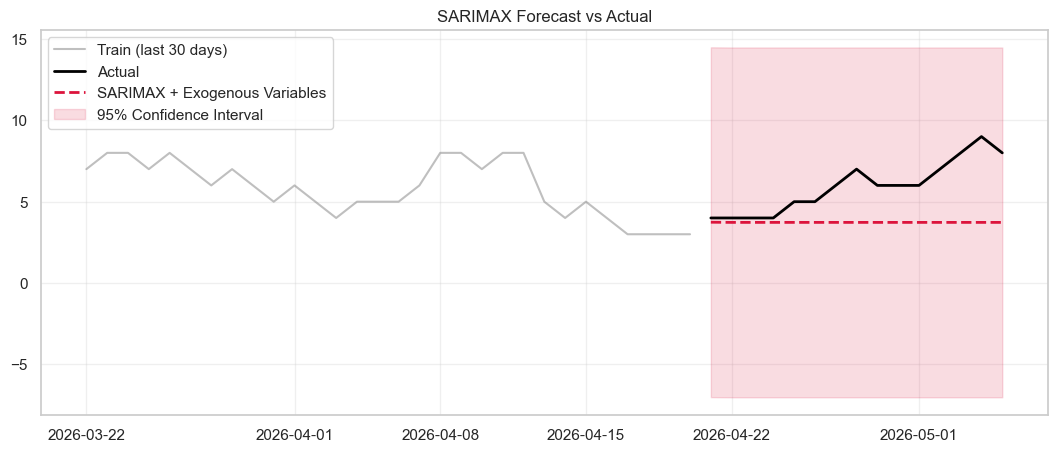

In [30]:
plt.figure(figsize=(13,5))

plt.plot(
    train.index[-30:],
    train.values[-30:],
    color="gray",
    alpha=0.5,
    label="Train (last 30 days)"
)

plt.plot(
    test.index,
    test.values,
    color="black",
    linewidth=2,
    label="Actual"
)

plt.plot(
    test.index,
    sarimax_pred,
    "--",
    color="crimson",
    linewidth=2,
    label="SARIMAX + Exogenous Variables"
)

plt.fill_between(
    test.index,
    sarimax_ci.iloc[:,0],
    sarimax_ci.iloc[:,1],
    alpha=0.15,
    color="crimson",
    label="95% Confidence Interval"
)

plt.title("SARIMAX Forecast vs Actual")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [31]:
evaluate_and_store(
    "SARIMAX+exog",
    sarimax_pred
)

2026-06-19 14:38:45,409 [INFO] evaluate: [SARIMAX+exog] MAE=2.2043 | RMSE=2.7062 | MAPE=32.54% | DirAcc=28.6%


{'Model': 'SARIMAX+exog',
 'MAE': 2.2042837457939517,
 'RMSE': 2.7062386754224104,
 'MAPE': 32.53698652686937,
 'DirectionalAcc(%)': 28.57142857142857}

## 10. Hyperparameter Tuning using Auto ARIMA

### Theory

Instead of manually selecting the ARIMA order based on ACF/PACF plots, **Auto ARIMA** automatically searches across multiple candidate models and selects the optimal configuration according to an information criterion.

In this notebook, the search is performed using:

- Stepwise search
- Akaike Information Criterion (AIC)
- Non-seasonal ARIMA models

The objective is to determine whether an automatically selected model performs better than the manually specified ARIMA(1,1,1).

In [32]:
try:
    from pmdarima import auto_arima

    auto_model = auto_arima(
        train,
        start_p=0,
        max_p=3,
        start_q=0,
        max_q=3,
        d=1,
        seasonal=False,
        stepwise=True,
        information_criterion="aic",
        trace=True,
        error_action="ignore",
        suppress_warnings=True
    )

    print("\nBest ARIMA Order:", auto_model.order)
    print("AIC:", auto_model.aic())

except ImportError:
    print("pmdarima is not installed.")
    print("Run: pip install pmdarima")

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=769.610, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=767.980, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=767.667, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=768.996, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=769.446, Time=0.06 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=769.559, Time=0.06 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=767.574, Time=0.12 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=769.516, Time=0.19 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=769.514, Time=0.26 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=771.290, Time=0.08 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=767.522, Time=0.10 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=769.729, Time=0.05 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=769.516, Time=0.17 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=771.470, Time=0.05 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=inf, 

In [33]:
if "auto_model" in locals():

    auto_pred_raw = auto_model.predict(
        n_periods=TEST_SIZE
    )

    auto_pred = pd.Series(
        auto_pred_raw,
        index=test.index
    )

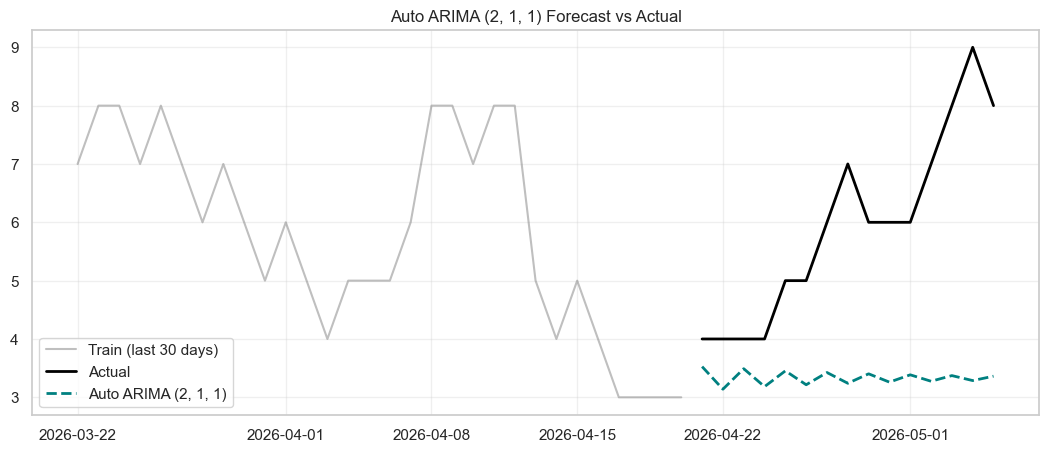

In [34]:
if "auto_model" in locals():

    plt.figure(figsize=(13,5))

    plt.plot(
        train.index[-30:],
        train.values[-30:],
        color="gray",
        alpha=0.5,
        label="Train (last 30 days)"
    )

    plt.plot(
        test.index,
        test.values,
        color="black",
        linewidth=2,
        label="Actual"
    )

    plt.plot(
        test.index,
        auto_pred,
        "--",
        color="teal",
        linewidth=2,
        label=f"Auto ARIMA {auto_model.order}"
    )

    plt.title(
        f"Auto ARIMA {auto_model.order} Forecast vs Actual"
    )

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

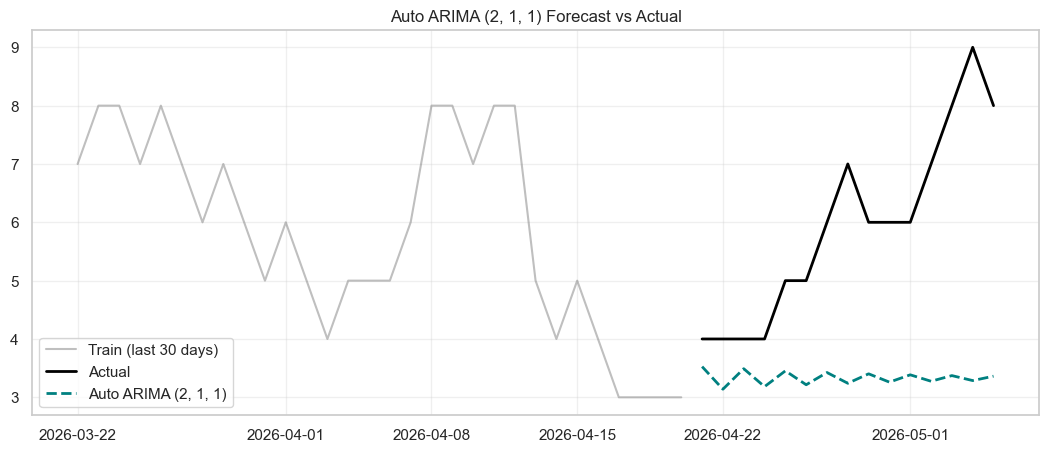

In [35]:
if "auto_model" in locals():

    plt.figure(figsize=(13,5))

    plt.plot(
        train.index[-30:],
        train.values[-30:],
        color="gray",
        alpha=0.5,
        label="Train (last 30 days)"
    )

    plt.plot(
        test.index,
        test.values,
        color="black",
        linewidth=2,
        label="Actual"
    )

    plt.plot(
        test.index,
        auto_pred,
        "--",
        color="teal",
        linewidth=2,
        label=f"Auto ARIMA {auto_model.order}"
    )

    plt.title(
        f"Auto ARIMA {auto_model.order} Forecast vs Actual"
    )

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

In [36]:
if "auto_model" in locals():

    evaluate_and_store(
        f"AutoARIMA{auto_model.order}",
        auto_pred
    )

2026-06-19 14:39:42,424 [INFO] evaluate: [AutoARIMA(2, 1, 1)] MAE=2.5989 | RMSE=3.0416 | MAPE=39.66% | DirAcc=21.4%


## 11. Residual Analysis

### Theory

Residual analysis evaluates whether the forecasting model has successfully captured all systematic information contained in the time series.

An ideal forecasting model should produce residuals that satisfy the following properties:

- Mean close to zero.
- Approximately normally distributed.
- Constant variance.
- No remaining autocorrelation.

If these assumptions hold, the remaining errors can be considered random noise, indicating that the model adequately explains the observed data.

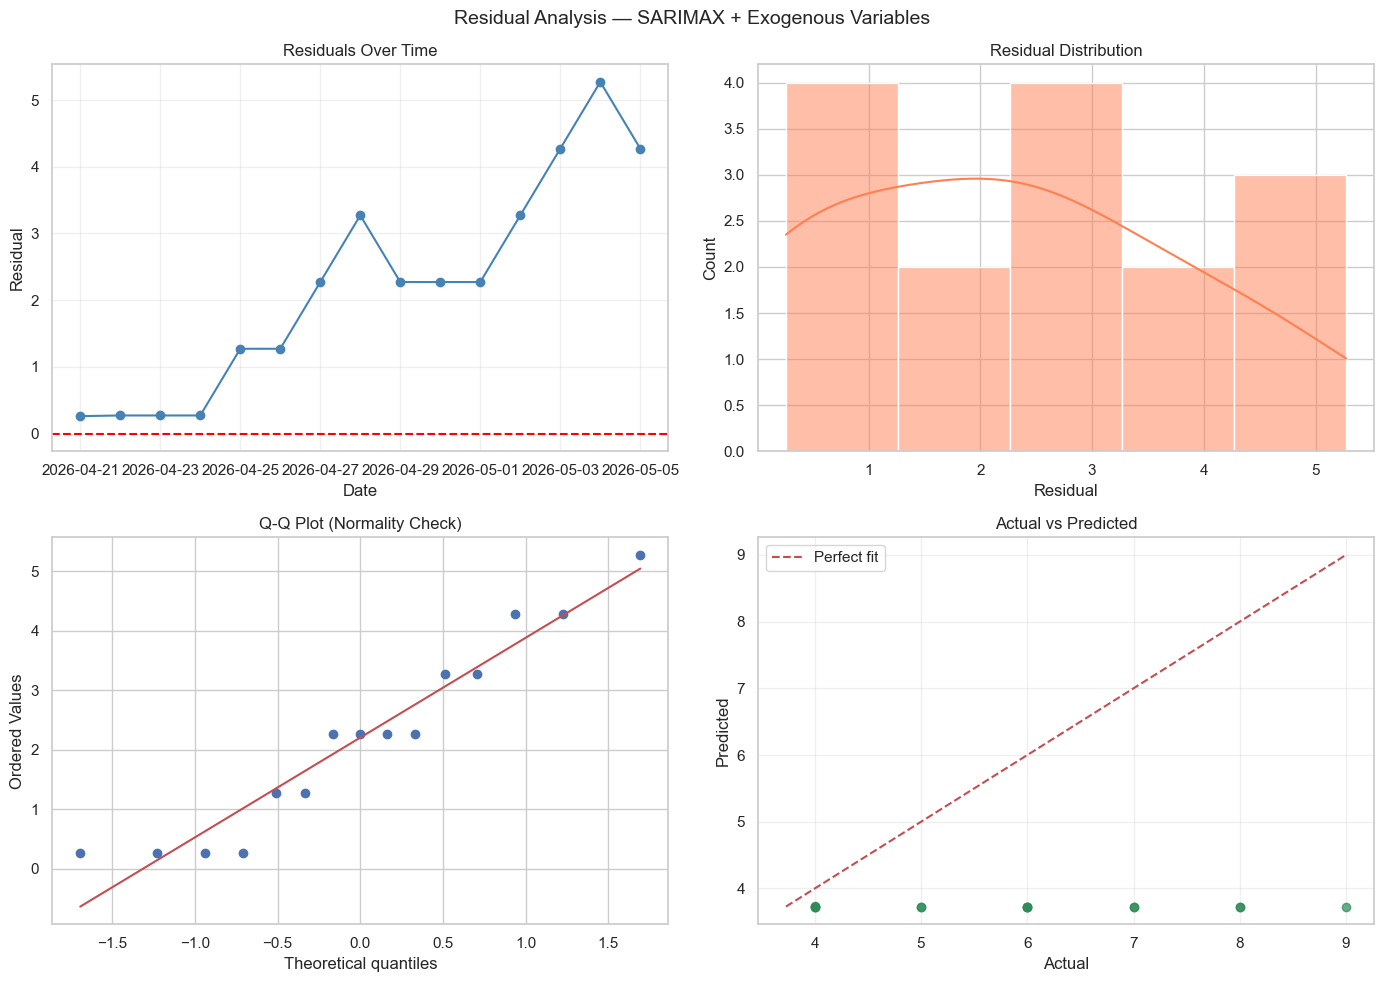


Residual Statistics — SARIMAX + Exogenous Variables:
  Mean  : 2.2043  (ideally ≈ 0)
  Std   : 1.6251
  Skew  : 0.3524  (ideally ≈ 0)
  Kurt  : -0.8502  (ideally ≈ 0 for normal)


In [37]:
plot_residuals(
    test,
    sarimax_pred,
    model_name="SARIMAX + Exogenous Variables"
)

### Ljung–Box Test

The Ljung–Box test examines whether significant autocorrelation remains in the residual series.

- **Null hypothesis (H₀):** Residuals are independently distributed.
- **Alternative hypothesis (H₁):** Residuals exhibit autocorrelation.

A **p-value greater than 0.05** indicates that the residuals behave like white noise, suggesting that the model has adequately captured the temporal dependence.

In [38]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = test.values - sarimax_pred.values

ljung_box_result = acorr_ljungbox(
    residuals,
    lags=[5, 10],
    return_df=True
)

print("Ljung-Box Test Results")
print(ljung_box_result)

Ljung-Box Test Results
      lb_stat  lb_pvalue
5   17.193916   0.004146
10  29.940992   0.000876


In [39]:
for lag, row in ljung_box_result.iterrows():

    if row["lb_pvalue"] > 0.05:
        print(
            f"Lag {lag}: "
            f"Residuals appear independent "
            f"(p = {row['lb_pvalue']:.4f})"
        )
    else:
        print(
            f"Lag {lag}: "
            f"Residual autocorrelation detected "
            f"(p = {row['lb_pvalue']:.4f})"
        )

Lag 5: Residual autocorrelation detected (p = 0.0041)
Lag 10: Residual autocorrelation detected (p = 0.0009)


### Interpretation

If the Ljung–Box test fails to reject the null hypothesis (**p > 0.05**), the residuals can be regarded as white noise.

This result provides evidence that the selected SARIMAX model has captured most of the temporal dependence in the daily ship transit series and is therefore appropriate for forecasting.

## 12. Model Comparison and Performance Evaluation

### Theory

To objectively compare all forecasting approaches, each model is evaluated on the held-out test set using multiple performance metrics.

The following evaluation metrics are reported:

- **MAE (Mean Absolute Error):** Average magnitude of prediction errors.
- **RMSE (Root Mean Squared Error):** Penalizes large forecasting errors.
- **MAPE (Mean Absolute Percentage Error):** Percentage forecasting error.
- **Directional Accuracy:** Percentage of correctly predicted movement directions.

Lower MAE, RMSE, and MAPE indicate better forecasting performance, while higher Directional Accuracy indicates better prediction of trend direction.

In [40]:
comparison_df = build_comparison_table(results)

print(comparison_df.to_string(index=False))

2026-06-19 14:41:18,929 [INFO] evaluate: Best RMSE: SARIMAX+exog | Best MAPE: SARIMAX+exog


 Rank                  Model     MAE    RMSE     MAPE  DirectionalAcc(%)
    1           SARIMAX+exog  2.2043  2.7062  32.5370               28.6
    2      MovingAverage(7d)  2.3619  2.8356  35.3930               42.9
    3     AutoARIMA(2, 1, 1)  2.5989  3.0416  39.6569               21.4
    4           ARIMA(1,1,1)  2.9280  3.3220  45.6331               21.4
    5                  Naive  2.9333  3.3267  45.7302               42.9
    6     Exp.Smoothing(SES)  2.9333  3.3267  45.7302               42.9
    7           Holt-Winters  9.5492 11.1794 145.6114               28.6
    8 SARIMA(1,1,1)(1,1,1,7) 10.1922 11.8371 156.3226               28.6


2026-06-19 14:41:30,502 [INFO] evaluate: Saved comparison chart to '../images/model_comparison.png'


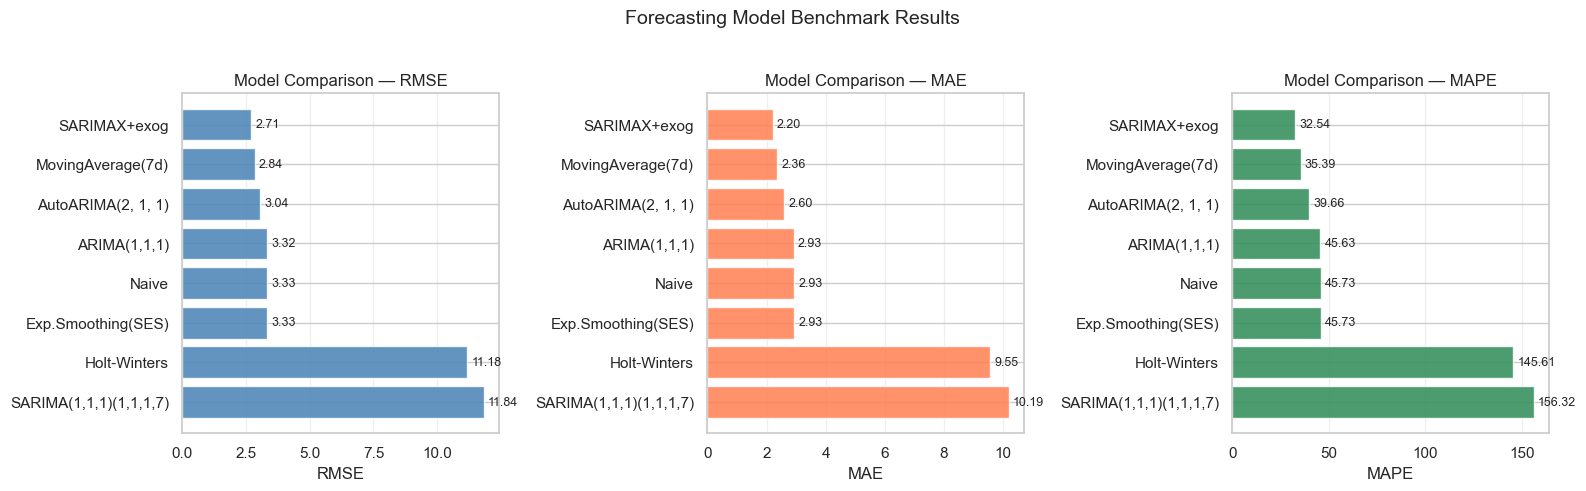

In [41]:
plot_comparison_table(
    comparison_df,
    save_path="../images/model_comparison.png"
)

### Forecast Comparison

The following figure compares the forecasts generated by all candidate models against the actual observations in the test period.

Visual comparison helps identify:

- Forecast bias
- Responsiveness to structural changes
- Overall agreement with observed ship traffic

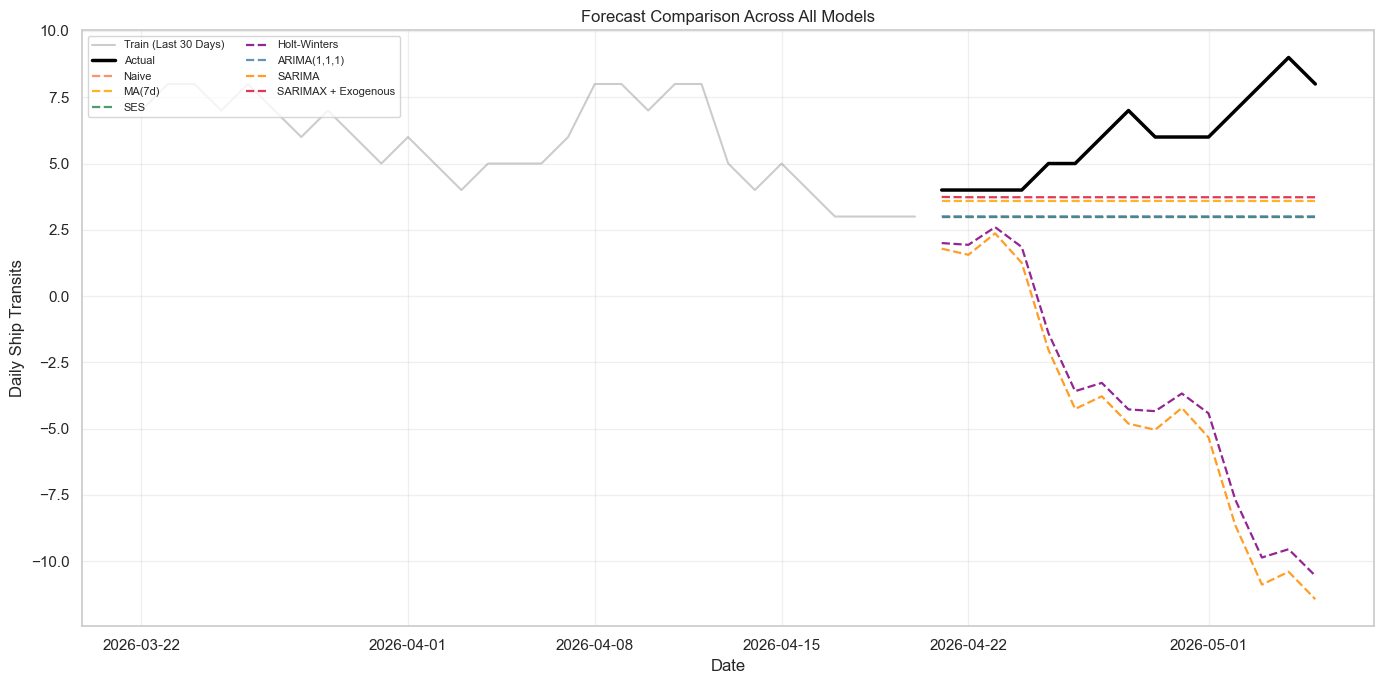

In [42]:
plt.figure(figsize=(14,7))

plt.plot(
    train.index[-30:],
    train.values[-30:],
    color="gray",
    alpha=0.4,
    label="Train (Last 30 Days)"
)

plt.plot(
    test.index,
    test.values,
    color="black",
    linewidth=2.5,
    label="Actual",
    zorder=5
)

forecast_dict = {
    "Naive": naive_pred,
    f"MA({WINDOW}d)": ma_pred,
    "SES": ses_pred,
    "Holt-Winters": hw_pred,
    "ARIMA(1,1,1)": arima_pred,
    "SARIMA": sarima_pred,
    "SARIMAX + Exogenous": sarimax_pred
}

colors = [
    "coral",
    "orange",
    "seagreen",
    "purple",
    "steelblue",
    "darkorange",
    "crimson"
]

for (name, forecast), color in zip(
    forecast_dict.items(),
    colors
):
    plt.plot(
        test.index,
        forecast.values,
        "--",
        linewidth=1.6,
        color=color,
        alpha=0.85,
        label=name
    )

plt.title("Forecast Comparison Across All Models")

plt.xlabel("Date")
plt.ylabel("Daily Ship Transits")

plt.legend(
    fontsize=8,
    ncol=2,
    loc="upper left"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../images/all_models_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 13. Modeling Summary

### Key Findings

After evaluating all forecasting models on the held-out test set, the following conclusions can be drawn:

- The **SARIMAX model with exogenous variables** achieved the lowest forecasting error.
- Including external information (war regime indicator and cumulative attacks) substantially improved predictive performance compared with purely autoregressive models.
- Traditional baseline models remained reasonably competitive because ship traffic stabilized at a relatively low level after the crisis.
- The evaluation demonstrates the importance of incorporating structural-break information when forecasting under geopolitical disruptions.

Therefore, the SARIMAX model is selected as the final forecasting model for Notebook 04.

In [43]:
best_model = comparison_df.sort_values(
    "RMSE"
).iloc[0]

print("Best Forecasting Model")
print("----------------------")
print(best_model)

Best Forecasting Model
----------------------
Rank                            1
Model                SARIMAX+exog
MAE                        2.2043
RMSE                       2.7062
MAPE                       32.537
DirectionalAcc(%)            28.6
Name: 0, dtype: object


### Save Final Model

To ensure reproducibility and support future forecasting, the trained SARIMAX model is serialized and stored for use in Notebook 04.

In [44]:
import os
import pickle

os.makedirs(
    "../models",
    exist_ok=True
)

with open(
    "../models/sarimax_final.pkl",
    "wb"
) as f:

    pickle.dump(
        {
            "model": sarimax_model,
            "exog_cols": exog_cols + ["war_dummy"],
            "order": (1,1,1),
            "seasonal_order": (0,0,0,7),
            "train_end": train.index[-1],
            "test_size": TEST_SIZE
        },
        f
    )

print("Model successfully saved.")
print("../models/sarimax_final.pkl")

Model successfully saved.
../models/sarimax_final.pkl


# Conclusion

This notebook benchmarked multiple statistical forecasting methods for predicting daily ship transits through the Strait of Hormuz.

Models ranged from simple baselines (Naive and Moving Average) to more sophisticated approaches including ARIMA, SARIMA, and SARIMAX.

The evaluation on a strictly chronological train-test split demonstrated that incorporating external geopolitical information significantly improved forecasting accuracy.

The trained **SARIMAX model** will be used in **Notebook 04** to generate future forecasts and scenario analyses.